Matplotlib is building the font cache; this may take a moment.


Real data not found. Using synthetic data for demo.

 (7, 4) shape:

First 5 rows:


,Flow Duration,Total Fwd Packets,Total Bwd Packets,Label
0,10000,5,2,BENIGN
1,50000,20,10,BENIGN
2,30000,15,8,DoS Hulk
3,1000,3,1,BENIGN
4,9000,4,1,BENIGN



Label Distribution:
Label
BENIGN      4
DoS Hulk    2
PortScan    1
Name: count, dtype: int64


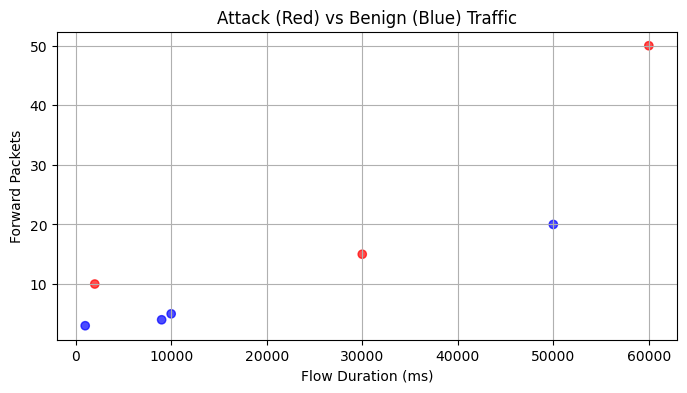


Simple Rule-Based Detection:
Predicted_Attack  ATTACK  BENIGN  All
Label                                
BENIGN                 1       3    4
DoS Hulk               2       0    2
PortScan               0       1    1
All                    3       4    7


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load Data (Synthetic if CICIDS2017 not found) ---
try:
    df = pd.read_csv('CICIDS2017_sample.csv')
    print("Real CICIDS2017 data loaded!")
except FileNotFoundError:
    print("Real data not found. Using synthetic data for demo.")
    df = pd.DataFrame({
        'Flow Duration': [10000, 50000, 30000, 1000, 9000, 2000, 60000],
        'Total Fwd Packets': [5, 20, 15, 3, 4, 10, 50],
        'Total Bwd Packets': [2, 10, 8, 1, 1, 5, 30],
        'Label': ['BENIGN', 'BENIGN', 'DoS Hulk', 'BENIGN', 'BENIGN', 'PortScan', 'DoS Hulk']
    })

print("\nDataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

# --- Basic Exploration ---
print("\nLabel Distribution:")
print(df['Label'].value_counts())

# --- Visualize Attack vs Benign Traffic ---
plt.figure(figsize=(8, 4))
plt.scatter(df['Flow Duration'], df['Total Fwd Packets'], 
            c=np.where(df['Label']=='BENIGN', 'blue', 'red'), alpha=0.7)
plt.xlabel('Flow Duration (ms)')
plt.ylabel('Forward Packets')
plt.title('Attack (Red) vs Benign (Blue) Traffic')
plt.grid()
plt.show()

# --- Simple Rule-Based Detection ---
print("\nSimple Rule-Based Detection:")
df['Predicted_Attack'] = np.where(
    (df['Flow Duration'] > 25000) | (df['Total Fwd Packets'] > 10), 
    'ATTACK', 'BENIGN'
)
print(pd.crosstab(df['Label'], df['Predicted_Attack'], margins=True))